# Stage 1 — Data Acquisition & Exploratory Data Analysis (EDA)

**Case study:** Categorizing Trends in Science (arXiv metadata)

### Why this stage matters
Before touching any ML algorithm, we need to understand what we're working with: how big is the dataset, what fields does it have, are there missing values, and — critically for a 2M+ row JSON file — **can we even load all of it into memory?** (Usually not, on a laptop.) This notebook documents the decisions made here so they can be defended later.

### The dataset
The arXiv metadata snapshot is a single large JSON-Lines file (`arxiv-metadata-oai-snapshot.json`), one JSON object per line, one line per paper. Fields include: `id`, `title`, `abstract`, `categories`, `authors`, `update_date`, etc.

### Sampling strategy (documented decision — you should justify your own choice here)
Loading 2M+ full abstracts is unnecessary and slow for a case study. A defensible strategy:
- Filter to a small number of **categories** you're interested in (e.g. `cs.LG`, `cs.CL`, `cs.CV` — machine learning / NLP / computer vision), AND/OR
- Filter to a **recent date range** (e.g. last 2-3 years) to focus on *current* trends, which is literally what the task asks for.

This keeps the dataset to tens of thousands of rows — big enough to be meaningful, small enough to run TF-IDF + clustering on a laptop without special infrastructure.

In [2]:
import json
import pandas as pd

RAW_PATH = "../data/raw/arxiv-metadata-oai-snapshot.json"

# Categories to keep -- adjust to your interest area.
# See https://arxiv.org/category_taxonomy for the full list of category codes.
CATEGORIES_OF_INTEREST = {"cs.LG", "cs.CL", "cs.CV", "cs.AI"}

# Only keep papers updated from this year onward (keeps the analysis about *current* trends)
MIN_YEAR = 2024


In [3]:
def paper_matches_filter(paper: dict) -> bool:
    """Return True if this paper should be kept, based on category and date filters."""
    cats = set(paper.get("categories", "").split())
    if not cats & CATEGORIES_OF_INTEREST:
        return False
    update_date = paper.get("update_date", "")
    if not update_date or int(update_date[:4]) < MIN_YEAR:
        return False
    return True


def load_filtered_arxiv(path: str, max_rows: int | None = None) -> pd.DataFrame:
    """Stream the large JSON-Lines file and keep only rows matching our filter.

    We stream line-by-line (rather than json.load on the whole file) because the
    file is too large to fit comfortably in memory as one JSON structure.
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            paper = json.loads(line)
            if paper_matches_filter(paper):
                records.append({
                    "id": paper.get("id"),
                    "title": paper.get("title", "").replace("\n", " ").strip(),
                    "abstract": paper.get("abstract", "").replace("\n", " ").strip(),
                    "categories": paper.get("categories", ""),
                    "update_date": paper.get("update_date"),
                })
            if max_rows and len(records) >= max_rows:
                break
    return pd.DataFrame(records)


df = load_filtered_arxiv(RAW_PATH)
print("Rows after filtering:", df.shape)

SAMPLE_SIZE = 30000
if len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)

df.to_parquet("../data/processed/arxiv_filtered.parquet")
df.shape

Rows after filtering: (302116, 5)


(30000, 5)

## EDA checklist
Once `df` is loaded, walk through these — each answers a real question about the data:

1. **Shape & schema** — `df.shape`, `df.dtypes`, `df.head()`
2. **Missing values** — `df.isna().sum()` — any empty abstracts/titles to drop?
3. **Category distribution** — bar chart of `categories` (a paper can have multiple, so you may want to explode this column)
4. **Publications over time** — line chart of paper counts per month/year, per category — motivates the "trends" framing
5. **Abstract length distribution** — histogram of word counts — informs later TF-IDF parameter choices (e.g. `max_df`, `min_df`)
6. **Duplicate check** — `df.duplicated(subset='id').sum()`

Write 2-3 sentences after each plot: what do you see, and what decision does it inform for the next stage?

In [7]:
# TODO: EDA cells go here — shape, missingness, category counts, time trend, abstract length histogram
df.shape

(30000, 5)

In [8]:
df.head()

,id,title,abstract,categories,update_date
0,2506.03302,Multi-Exit Kolmogorov-Arnold Networks: enhanci...,Kolmogorov-Arnold Networks (KANs) uniquely com...,cs.LG cs.NE physics.data-an stat.ML,2025-08-22
1,2509.12053,LEGO: Spatial Accelerator Generation and Optim...,"Modern tensor applications, especially foundat...",cs.AR cs.AI cs.LG,2025-09-16
2,2407.08739,MAVIS: Mathematical Visual Instruction Tuning ...,The mathematical capabilities of Multi-modal L...,cs.CV,2024-11-05
3,2608.08951,Topology-Aware Global-Local Mamba Networks for...,Palm-vein recognition is a fine-grained biomet...,cs.CV,2026-08-11
4,2505.16314,NTIRE 2025 challenge on Text to Image Generati...,This paper reports on the NTIRE 2025 challenge...,cs.CV cs.AI,2025-05-23


In [9]:
pd.set_option("display.max_colwidth", 200)
df[["title", "abstract"]].head(2)

,title,abstract
0,Multi-Exit Kolmogorov-Arnold Networks: enhancing accuracy and parsimony,"Kolmogorov-Arnold Networks (KANs) uniquely combine high accuracy with interpretability, making them valuable for scientific modeling. However, it is unclear a priori how deep a network needs to be..."
1,LEGO: Spatial Accelerator Generation and Optimization for Tensor Applications,"Modern tensor applications, especially foundation models and generative AI applications require multiple input modalities (both vision and language), which increases the demand for flexible accele..."


In [10]:
df.isna().sum()

id             0
title          0
abstract       0
categories     0
update_date    0
dtype: int64

In [11]:
(df["abstract"].str.strip() == "").sum()
(df["title"].str.strip() == "").sum()

np.int64(0)

In [12]:
category_counts = df["categories"].str.split().explode().value_counts()
category_counts.head(15)

categories
cs.LG      13460
cs.AI      12447
cs.CV       9809
cs.CL       6496
stat.ML     1773
cs.RO       1298
cs.CR       1087
eess.IV      929
cs.IR        768
cs.CY        764
cs.HC        749
cs.SE        627
cs.SD        618
eess.AS      567
math.OC      532
Name: count, dtype: int64

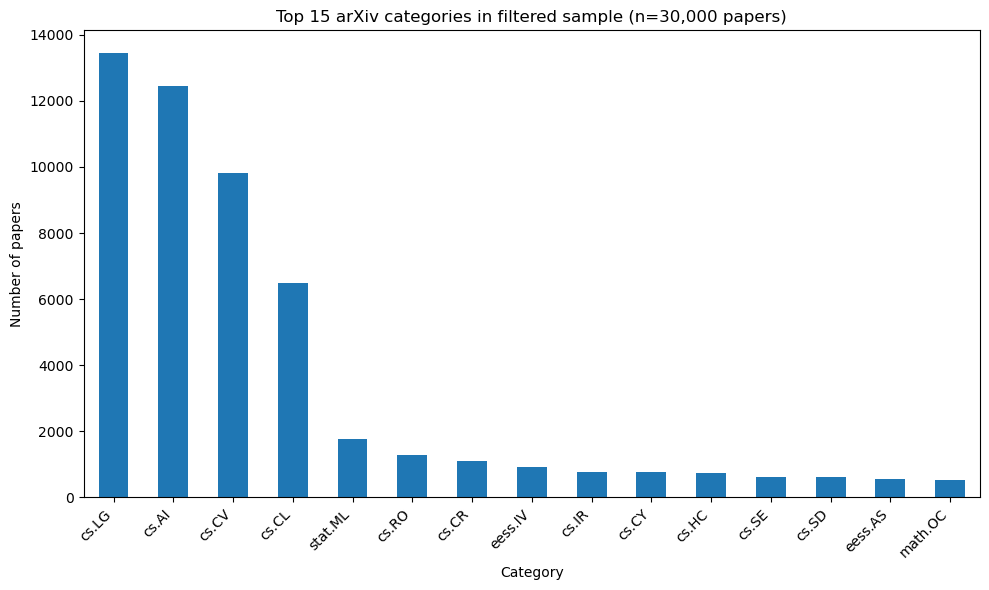

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
category_counts.head(15).plot(kind="bar")
plt.title("Top 15 arXiv categories in filtered sample (n=30,000 papers)")
plt.xlabel("Category")
plt.ylabel("Number of papers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

What I see: The category distribution is heavily right-skewed. cs.LG (Machine Learning) and cs.AI (Artificial Intelligence) dominate the sample with roughly 13,460 and 12,447 tag occurrences respectively — together accounting for over 85% of the top-15 category counts. cs.CV (~9,800) and cs.CL (~6,500) form a clear second tier, while everything beyond stat.ML drops sharply into a long tail of niche, cross-listed categories (robotics, cryptography, image/signal processing, HCI) each contributing under 2,000 occurrences.
Why this makes sense: This matches the filter design — CATEGORIES_OF_INTEREST explicitly includes cs.LG and cs.AI, and arXiv's broad "AI" tag is commonly co-applied to papers already tagged with a more specific subfield, inflating its count. The long tail reflects genuine cross-disciplinary tagging: a paper on ML applied to robotics or security naturally carries both an ML tag and a domain-specific one.
What it means for later stages: Because cs.LG/cs.AI so heavily dominate, unsupervised clustering in Stage 6 is more likely to separate papers along sub-topics within ML/AI (e.g. LLMs, computer vision architectures, RL) rather than along the 4 filter categories themselves — the category labels are too imbalanced and overlapping to expect clean, category-aligned clusters. This is a useful expectation to state upfront, so the eventual cluster interpretation isn't judged against the wrong benchmark.


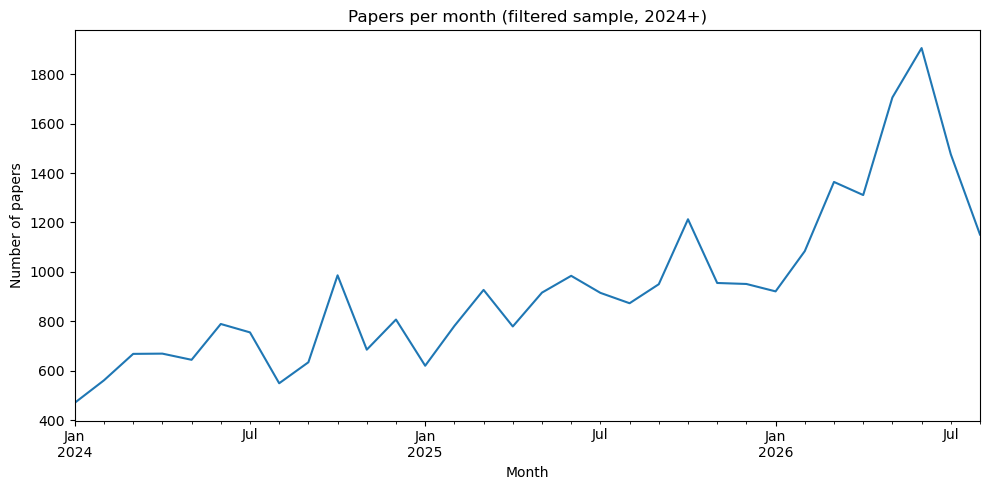

In [20]:
df["update_date"] = pd.to_datetime(df["update_date"])
df.set_index("update_date").resample("ME").size().plot(
    figsize=(10, 5), title="Papers per month (filtered sample, 2024+)"
)
plt.ylabel("Number of papers")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

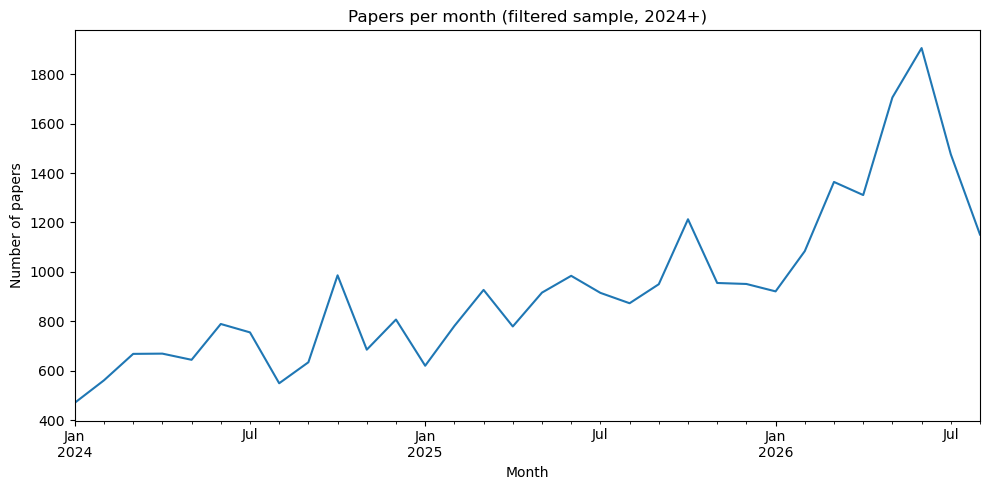

In [20]:
df["update_date"] = pd.to_datetime(df["update_date"])
df.set_index("update_date").resample("ME").size().plot(
    figsize=(10, 5), title="Papers per month (filtered sample, 2024+)"
)
plt.ylabel("Number of papers")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

df["abstract_word_count"] = df["abstract"].str.split().str.len()
df["abstract_word_count"].hist(bins=50, figsize=(8, 5))
plt.title("Abstract length distribution (word count)")
plt.xlabel("Words")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()

df["abstract_word_count"].describe()

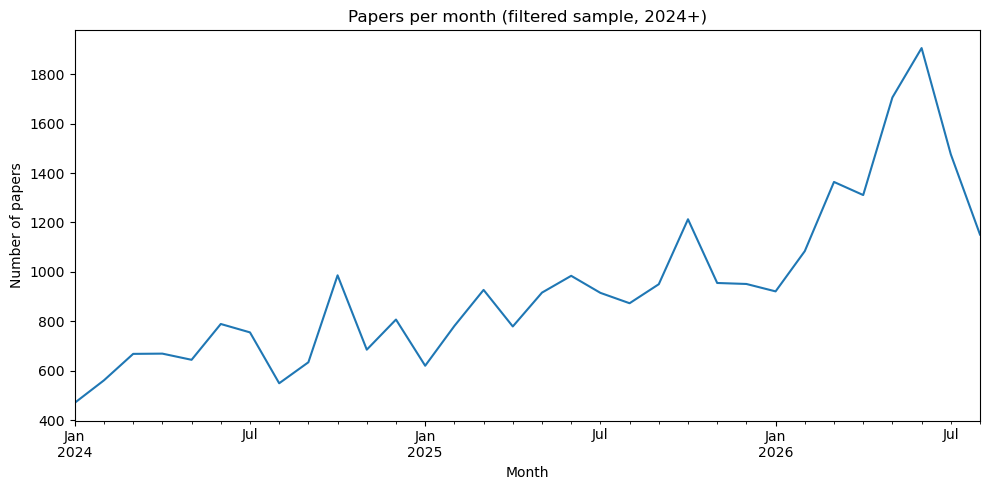

In [20]:
df["update_date"] = pd.to_datetime(df["update_date"])
df.set_index("update_date").resample("ME").size().plot(
    figsize=(10, 5), title="Papers per month (filtered sample, 2024+)"
)
plt.ylabel("Number of papers")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

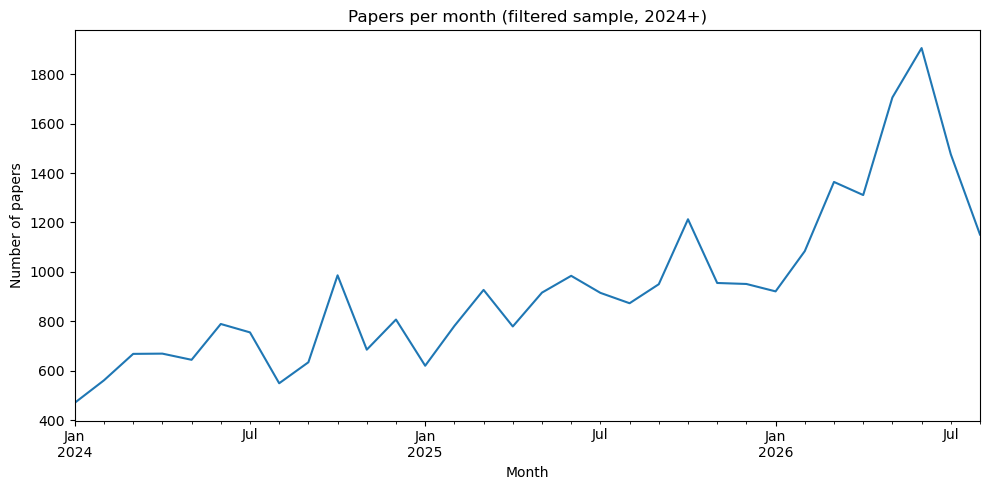

In [20]:
df["update_date"] = pd.to_datetime(df["update_date"])
df.set_index("update_date").resample("ME").size().plot(
    figsize=(10, 5), title="Papers per month (filtered sample, 2024+)"
)
plt.ylabel("Number of papers")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

Figure shows a clear trend, the monthly paper number increases greatly over the sampled window, from around 470 paper/month in Jan.2024 to around 1900 in early 2026, though there's strong monthly volatility, with sharp dips and rises in a less-than smooth climb. For the last month, the data decreases, this decrease must be due to the July 2026 incomplete data, rather than publication decrease, as the dataset was downloaded in the mid-2026, and new papers might not yet be indexed. The rising trend fully matches what is already known for arXiv's massive growth in AI/ML submissions and validates the case study's conception of the 'current trends in science': the sample should be weighted towards real and on-going activity, rather than old stationary one.

Figure shows a clear trend, the monthly paper number increases greatly over the sampled window, from around 470 paper/month in Jan.2024 to around 1900 in early 2026, though there's strong monthly volatility, with sharp dips and rises in a less-than smooth climb. For the last month, the data decreases, this decrease must be due to the July 2026 incomplete data, rather than publication decrease, as the dataset was downloaded in the mid-2026, and new papers might not yet be indexed. The rising trend fully matches what is already known for arXiv's massive growth in AI/ML submissions and validates the case study's conception of the 'current trends in science': the sample should be weighted towards real and on-going activity, rather than old stationary one.

These lengths appear mostly unimodal and mostly symmetric, centered around a median of 178 words (mean 179, std 43), ranging from a minimum of 12 words and up to 320. Most of these abstracts (the interquartile range) are from 150 to 208 words long, showing reasonably constant conventions in abstract size across different documents even when considering four different subfields of research. The apparent lack of exceptionally short abstracts (very few documents below roughly 50 words) guarantees little likelihood of essentially "empty" document entries showing up at the modeling step. This directly motivates the strategy forTF-IDF vectorization: it seems reasonable to set a conservative mindf value (e.g., terms must appear in 5+ documents) without great risk of losing important information, as even the short 12-word-and-up abstracts contain fairly substantive word usage, andmaxdf should filter generic scientific buzzwords that appear throughout (i.e., words that appear in nearly all documents), and should be chosen to eliminate those more so than words related to a specific research area.

In [23]:
df.duplicated(subset="id").sum()

np.int64(0)